<a href="https://colab.research.google.com/github/Just1919/Formation_NLP/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Automating Text Vectorization

In [ ]:
#Import required librairies
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Embedding
from tensorflow.keras.layers import TextVectorization, InputLayer
import tensorflow as tf

In [ ]:
max_words = 10000
max_length = 500

model = Sequential()
model.add(InputLayer(shape=(1,), dtype=tf.string))
model.add(TextVectorization(max_tokens=max_words, output_sequence_length=max_length))
model.add(Embedding(max_words, 32))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,048,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,368,257 (9.03 MB)

 Trainable params: 2,368,257 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import pandas
df = pd.read_csv('/content/drive/MyDrive/reviews.csv', encoding="ISO-8859-1")
df = df.sample(frac=1, random_state=0)
df.head()

,Text,Sentiment
11841,Al Pacino was once an actor capable of making ...,0
19602,After Chaplin made one of his best films: Doug...,0
45519,This movie is sort of a Carrie meets Heavy Met...,1
25747,I have fond memories of watching this visually...,1
42642,"In the '70s, Charlton Heston starred in sci-fi...",1


In [ ]:
#Remove duplicate rows
df=df.drop_duplicates()

In [ ]:
df.groupby("Sentiment").describe()

Text                                                               
           count unique                                                top freq
Sentiment                                                                      
0          24697  24697  What could've been a great film about the late...    1
1          24884  24884  I really enjoyed this film. All aspects of the...    1

In [ ]:
#Split the dataset
x=df["Text"]
y=df["Sentiment"]
model.layers[0].adapt(x)

In [ ]:
hist = model.fit(tf.constant(x), y, validation_split=0.5, epochs=5, batch_size=250)


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 190ms/step - accuracy: 0.7126 - loss: 0.5288 - val_accuracy: 0.8374 - val_loss: 0.3621
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 245ms/step - accuracy: 0.9178 - loss: 0.2149 - val_accuracy: 0.8652 - val_loss: 0.3158
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step - accuracy: 0.9791 - loss: 0.0794 - val_accuracy: 0.8521 - val_loss: 0.4036
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 220ms/step - accuracy: 0.9973 - loss: 0.0216 - val_accuracy: 0.8563 - val_loss: 0.4295
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 242ms/step - accuracy: 0.9994 - loss: 0.0074 - val_accuracy: 0.8531 - val_loss: 0.4952


[]

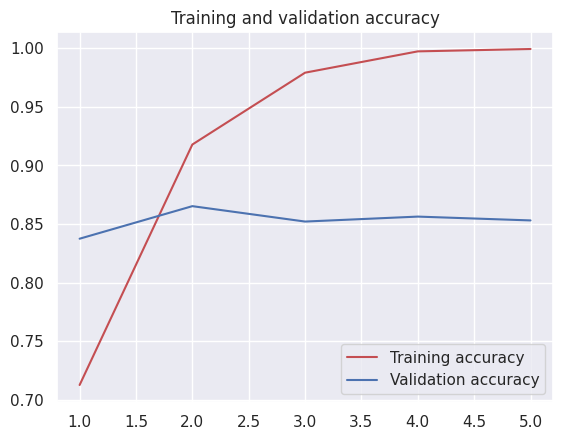

In [ ]:
from numpy import e
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

acc=hist.history['accuracy']
val_acc=hist.history['val_accuracy']
epochs=range(1, len(acc)+1)

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc='lower right')
plt.plot()

In [ ]:
#Make a prediction
text="Excellent foof and fantastic service"
model.predict(tf.constant([text]))[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


np.float32(0.99947447)

In [ ]:
model.save("sentiment_model.keras")           # saves as a folder
